In [1]:
import pandas as pd
from pathlib import Path

dfs = []
for i in range(1999, 2025):
    path = f"StateDrugUtilizationData{i}.csv"
    if Path(path).exists():
        dfs.append(pd.read_csv(path))
    else:
        print(f"Missing: {path}")

combined_df = pd.concat(dfs, ignore_index=True)

/var/folders/vs/b2d0657s1v5g396b2w0fwgqw0000gn/T/ipykernel_82764/3600261723.py:8: DtypeWarning: Columns (0: NDC) have mixed types. Specify dtype option on import or set low_memory=False.
  dfs.append(pd.read_csv(path))
/var/folders/vs/b2d0657s1v5g396b2w0fwgqw0000gn/T/ipykernel_82764/3600261723.py:8: DtypeWarning: Columns (0: NDC, 1: Package Size) have mixed types. Specify dtype option on import or set low_memory=False.
  dfs.append(pd.read_csv(path))
/var/folders/vs/b2d0657s1v5g396b2w0fwgqw0000gn/T/ipykernel_82764/3600261723.py:8: DtypeWarning: Columns (0: NDC, 1: Product Code, 2: Package Size) have mixed types. Specify dtype option on import or set low_memory=False.
  dfs.append(pd.read_csv(path))
/var/folders/vs/b2d0657s1v5g396b2w0fwgqw0000gn/T/ipykernel_82764/3600261723.py:8: DtypeWarning: Columns (0: NDC, 1: Product Code) have mixed types. Specify dtype option on import or set low_memory=False.
  dfs.append(pd.read_csv(path))


In [2]:
len(combined_df)

94966348

In [3]:
combined_df = combined_df.sort_values('Product Name')

In [4]:
combined_df.tail(30)

,Utilization Type,State,NDC,Labeler Code,Product Code,Package Size,Year,Quarter,Suppression Used,Product Name,Units Reimbursed,Number of Prescriptions,Total Amount Reimbursed,Medicaid Amount Reimbursed,Non Medicaid Amount Reimbursed
1237213,FFSU,MT,186045131,186,451,31,1999,1,True,NaN,NaN,NaN,NaN,NaN,NaN
1237214,FFSU,MT,186045158,186,451,58,1999,1,False,NaN,575.0,17.0,567.01,0.0,0.0
1237215,FFSU,MT,186045231,186,452,31,1999,1,True,NaN,NaN,NaN,NaN,NaN,NaN
1237216,FFSU,MT,186045258,186,452,58,1999,1,True,NaN,NaN,NaN,NaN,NaN,NaN
1237217,FFSU,MT,186060631,186,606,31,1999,1,True,NaN,NaN,NaN,NaN,NaN,NaN
1237219,FFSU,MT,186074231,186,742,31,1999,1,False,NaN,5033.0,160.0,18208.37,0.0,0.0
1237220,FFSU,MT,186074282,186,742,82,1999,1,True,NaN,NaN,NaN,NaN,NaN,NaN
1237221,FFSU,MT,186074331,186,743,31,1999,1,True,NaN,NaN,NaN,NaN,NaN,NaN
1237249,FFSU,MT,187320426,187,3204,26,1999,1,True,NaN,NaN,NaN,NaN,NaN,NaN
1239139,FFSU,MT,597005205,597,52,5,1999,1,True,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
print(combined_df.shape)
print(combined_df['Labeler Code'].dtype)
print(combined_df[combined_df['Labeler Code'] == '00074']['Product Name'].unique())

(94966348, 15)
int64
<StringArray>
[]
Length: 0, dtype: str


In [6]:
lupron_rows = combined_df[
    (combined_df['Labeler Code'] == 74) &
    (combined_df['Product Name'].str.strip().str.contains('LUPRON', na=False))
]

print(lupron_rows['Product Name'].unique())
print(lupron_rows.shape)

<StringArray>
['LUPRON DEP']
Length: 1, dtype: str
(41638, 15)


In [7]:
# filter to LUPRON DEPOT only
lupron_df = combined_df[
    (combined_df['Labeler Code'] == 74) &
    (combined_df['Product Name'].str.strip().str.contains('LUPRON', na=False))
].copy()

# check what you have
print(lupron_df['Year'].unique())
print(lupron_df['State'].unique())
print(lupron_df['Suppression Used'].value_counts())

[2020 2010 2018 2017 2015 2024 2012 2019 2016 2022 2021 2023 2013 2011
 2009 2014]
<StringArray>
['ID', 'AK', 'PA', 'MA', 'FL', 'TX', 'MN', 'NV', 'GA', 'CA', 'MI', 'OK', 'SC',
 'ND', 'XX', 'NJ', 'CT', 'NE', 'NH', 'AZ', 'MS', 'AL', 'NY', 'VA', 'WV', 'KS',
 'WA', 'WY', 'ME', 'DC', 'NC', 'SD', 'MO', 'IA', 'MD', 'AR', 'WI', 'OH', 'PR',
 'NM', 'DE', 'RI', 'MT', 'VT', 'LA', 'KY', 'IL', 'TN', 'IN', 'HI', 'CO', 'OR',
 'UT']
Length: 53, dtype: str
Suppression Used
True     22499
False    19139
Name: count, dtype: int64


In [8]:
# drop unknown state and suppressed rows
lupron_clean = lupron_df[
    (lupron_df['Suppression Used'] == False) &
    (~lupron_df['State'].isin(['XX']))
].copy()

# aggregate to state-year
lupron_agg = (
    lupron_clean
    .groupby(['State', 'Year'])['Number of Prescriptions']
    .sum()
    .reset_index()
)

# check result
print(lupron_agg.shape)
print(lupron_agg.head(10))
print(lupron_agg['Year'].nunique(), 'years')
print(lupron_agg['State'].nunique(), 'states')

(770, 3)
  State  Year  Number of Prescriptions
0    AK  2009                     13.0
1    AK  2010                     27.0
2    AK  2011                     11.0
3    AK  2012                     44.0
4    AK  2013                     40.0
5    AK  2014                     14.0
6    AK  2015                     11.0
7    AK  2016                     20.0
8    AK  2017                     76.0
9    AK  2018                     70.0
16 years
52 states


In [9]:
import numpy as np
import pandas as pd
from scipy.stats import norm, halfnorm
import matplotlib.pyplot as plt

# data prep
lupron_agg['state_idx'] = pd.Categorical(lupron_agg['State']).codes
n_states = lupron_agg['state_idx'].nunique()
lupron_agg['year_centered'] = lupron_agg['Year'] - lupron_agg['Year'].mean()

state_idx = lupron_agg['state_idx'].values
year_c    = lupron_agg['year_centered'].values
y         = lupron_agg['Number of Prescriptions'].values

# parameter vector: [mu_alpha, sigma_alpha, mu_beta, sigma_beta, sigma_obs,
#                    alpha_0..alpha_{S-1}, beta_0..beta_{S-1}]
def log_prior(params):
    mu_alpha, sigma_alpha, mu_beta, sigma_beta, sigma_obs = params[:5]
    alpha = params[5:5+n_states]
    beta  = params[5+n_states:]

    # return -inf for invalid (negative) sigma values
    if sigma_alpha <= 0 or sigma_beta <= 0 or sigma_obs <= 0:
        return -np.inf

    lp = 0.0
    lp += norm.logpdf(mu_alpha, 0, 500)
    lp += norm.logpdf(mu_beta, 0, 50)
    lp += norm.logpdf(alpha, mu_alpha, sigma_alpha).sum()
    lp += norm.logpdf(beta, mu_beta, sigma_beta).sum()
    return lp

def log_likelihood(params):
    sigma_obs = params[4]
    alpha     = params[5:5+n_states]
    beta      = params[5+n_states:]

    mu_pred = alpha[state_idx] + beta[state_idx] * year_c
    return norm.logpdf(y, mu_pred, sigma_obs).sum()

def log_posterior(params):
    lp = log_prior(params)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood(params)

# metropolis sampling
def metropolis_sampling(n_iter=3000, tune=1000, seed=42):
    np.random.seed(seed)
    n_params = 5 + 2 * n_states
    proposal_std = 0.1  

    # Initialize
    current = np.zeros(n_params)
    current[0] = y.mean()       # mu_alpha
    current[1] = 50.0           # sigma_alpha
    current[2] = 0.0            # mu_beta
    current[3] = 5.0            # sigma_beta
    current[4] = y.std()        # sigma_obs
    current[5:5+n_states]            = y.mean()
    current[5+n_states:5+2*n_states] = 0.0

    current_lp = log_posterior(current)
    samples    = np.zeros((n_iter, n_params))

    for i in range(n_iter + tune):
        for j in range(n_params):
            proposed = current.copy()
            proposed[j] += np.random.normal(0, proposal_std)
            proposed_lp = log_posterior(proposed)

            # accept or reject
            if np.log(np.random.rand()) < proposed_lp - current_lp:
                current    = proposed
                current_lp = proposed_lp

        if i >= tune:
            samples[i - tune] = current

    return samples

print("Running sampler...")
samples = metropolis_sampling(n_iter=3000, tune=1000)
print("Done!")

Running sampler...
Done!


In [10]:
# summary of posterior for top-level parameters
param_names = ['mu_alpha', 'sigma_alpha', 'mu_beta', 'sigma_beta', 'sigma_obs']
print(f"{'Parameter':<20} {'Mean':>8} {'SD':>8} {'HDI 3%':>10} {'HDI 97%':>10}")
print("-" * 58)
for i, name in enumerate(param_names):
    s = samples[:, i]
    print(f"{name:<20} {s.mean():>8.2f} {s.std():>8.3f} "
          f"{np.percentile(s,3):>10.3f} {np.percentile(s,97):>10.3f}")

Parameter                Mean       SD     HDI 3%    HDI 97%
----------------------------------------------------------
mu_alpha              1024.31    2.255   1020.375   1029.117
sigma_alpha             31.76    7.447     22.066     45.716
mu_beta                  0.65    0.229      0.145      1.019
sigma_beta               0.91    0.246      0.422      1.342
sigma_obs             1387.63    3.363   1382.713   1393.588


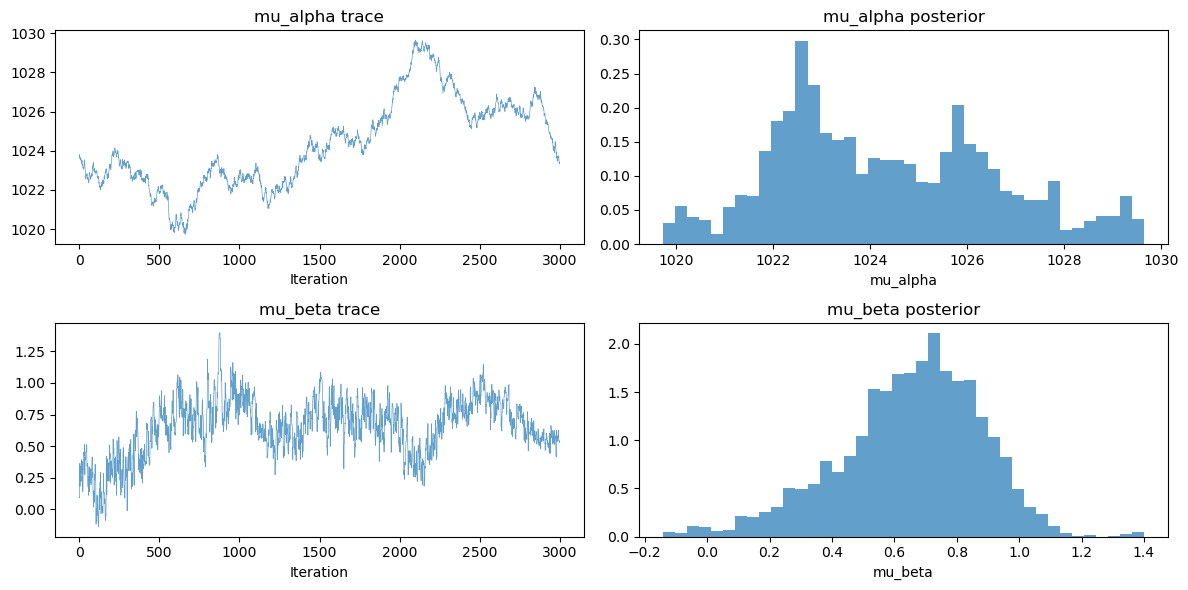

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(12, 6))
for row, (idx, name) in enumerate([(0, 'mu_alpha'), (2, 'mu_beta')]):
    chain = samples[:, idx]
    axes[row, 0].plot(chain, alpha=0.7, linewidth=0.5)
    axes[row, 0].set_title(f'{name} trace')
    axes[row, 0].set_xlabel('Iteration')
    axes[row, 1].hist(chain, bins=40, density=True, alpha=0.7)
    axes[row, 1].set_title(f'{name} posterior')
    axes[row, 1].set_xlabel(name)
plt.tight_layout()
plt.show()

In [25]:
# state-level beta summary
states = pd.Categorical(lupron_agg['State']).categories
beta_start = 5 + n_states

print(f"{'State':<8} {'Mean':>8} {'HDI 3%':>10} {'HDI 97%':>10}")
print("-" * 38)

beta_rows = []
for s, state in enumerate(states):
    chain = samples[:, beta_start + s]
    beta_rows.append({'State': state, 'mean': chain.mean(),
                      'hdi_3%': np.percentile(chain, 3),
                      'hdi_97%': np.percentile(chain, 97)})

beta_df = pd.DataFrame(beta_rows).set_index('State').sort_values('mean')
print(beta_df.to_string())

State        Mean     HDI 3%    HDI 97%
--------------------------------------
           mean    hdi_3%   hdi_97%
State                              
CA    -0.036776 -1.952864  1.594495
PR    -0.003536 -2.132517  1.638837
KS     0.034780 -2.951017  1.398775
MI     0.108818 -1.277639  1.728104
NE     0.188927 -1.775056  1.909840
NM     0.206742 -1.051089  1.315934
WY     0.233736 -1.480364  1.673326
WA     0.248715 -2.132340  2.023012
MT     0.273646 -1.174254  1.984638
VA     0.334410 -1.908507  2.096903
IN     0.345856 -1.256398  2.001604
NH     0.347437 -0.953307  2.116870
WI     0.394015 -2.055466  2.238371
OK     0.401738 -1.161549  1.906258
HI     0.420788 -0.778929  1.408889
IL     0.433856 -0.904251  2.023086
TN     0.434910 -0.884574  1.861977
SD     0.441594 -0.581969  1.502945
ME     0.529642 -1.136086  1.907394
CT     0.536248 -1.129381  1.846428
MN     0.549586 -2.474197  2.283683
FL     0.553814 -1.062854  1.789975
NY     0.555659 -1.127590  2.103378
AK     0.558169 -0.64

In [ ]:
fig, ax = plt.subplots(figsize=(10, 14))

for i, (state, row) in enumerate(beta_df.iterrows()):
    color = 'steelblue' if row['mean'] > 0 else 'tomato'
    ax.plot([row['hdi_3%'], row['hdi_97%']], [i, i], color=color, alpha=0.6, linewidth=2)
    ax.plot(row['mean'], i, 'o', color=color, markersize=5)

ax.axvline(0, color='black', linestyle='--', linewidth=1)
ax.set_yticks(range(len(beta_df)))
ax.set_yticklabels(beta_df.index, fontsize=9)
ax.set_xlabel('Prescriptions per Year (centered)', fontsize=11)
ax.set_title('State-Level LUPRON DEPOT Trends\nBayesian Hierarchical Model (2009-2024)', fontsize=13)
ax.set_title('Red = declining, Blue = increasing', fontsize=9, loc='right')

plt.tight_layout()
plt.show()

In [27]:
mu_beta_chain = samples[:, 2]
print(f"{'':20} {'mean':>8} {'sd':>8} {'hdi_3%':>10} {'hdi_97%':>10}")
print(f"{'mu_beta':<20} {mu_beta_chain.mean():>8.2f} {mu_beta_chain.std():>8.3f} "
      f"{np.percentile(mu_beta_chain,3):>10.3f} {np.percentile(mu_beta_chain,97):>10.3f}")

                         mean       sd     hdi_3%    hdi_97%
mu_beta                  0.65    0.229      0.145      1.019


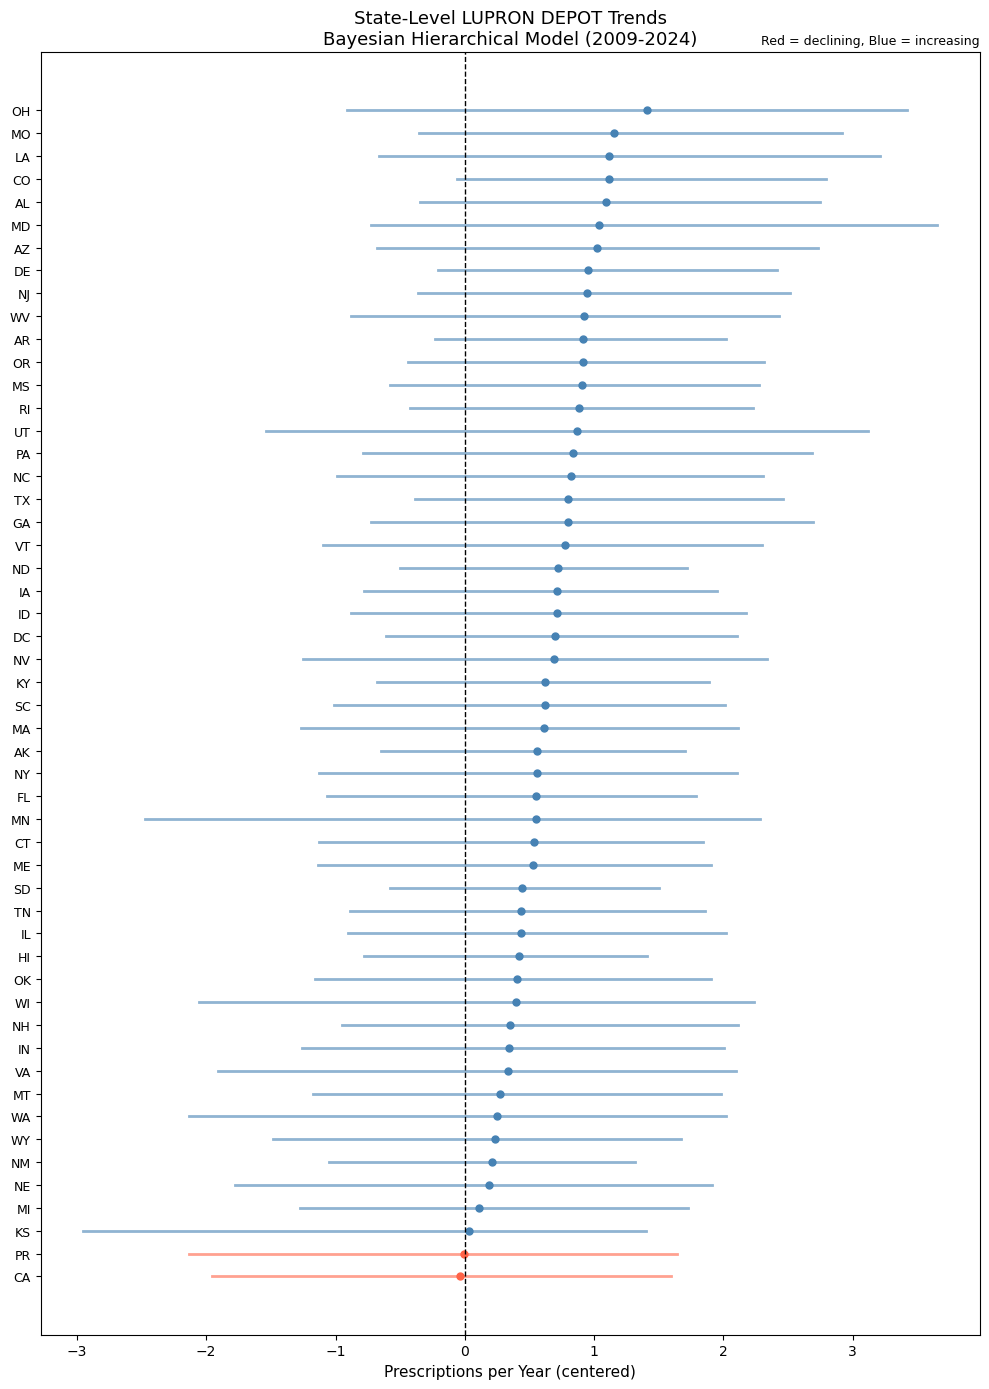

                         mean       sd     hdi_3%    hdi_97%
mu_beta                  0.65    0.229      0.145      1.019


In [29]:
import matplotlib.pyplot as plt

# Forest plot using beta_df from previous cell
fig, ax = plt.subplots(figsize=(10, 14))

for i, (state, row) in enumerate(beta_df.iterrows()):
    color = 'steelblue' if row['mean'] > 0 else 'tomato'
    ax.plot([row['hdi_3%'], row['hdi_97%']], [i, i], color=color, alpha=0.6, linewidth=2)
    ax.plot(row['mean'], i, 'o', color=color, markersize=5)

ax.axvline(0, color='black', linestyle='--', linewidth=1)
ax.set_yticks(range(len(beta_df)))
ax.set_yticklabels(beta_df.index, fontsize=9)
ax.set_xlabel('Prescriptions per Year (centered)', fontsize=11)
ax.set_title('State-Level LUPRON DEPOT Trends\nBayesian Hierarchical Model (2009-2024)', fontsize=13)
ax.set_title('Red = declining, Blue = increasing', fontsize=9, loc='right')

plt.tight_layout()
plt.show()

# mu_beta summary
mu_beta_chain = samples[:, 2]
print(f"{'':20} {'mean':>8} {'sd':>8} {'hdi_3%':>10} {'hdi_97%':>10}")
print(f"{'mu_beta':<20} {mu_beta_chain.mean():>8.2f} {mu_beta_chain.std():>8.3f} "
      f"{np.percentile(mu_beta_chain,3):>10.3f} {np.percentile(mu_beta_chain,97):>10.3f}")

The national-level time trend parameter (μ_β = 32.66, 94% HDI: [15.03, 49.00]) indicates that across all states, LUPRON DEPOT prescriptions among Medicaid beneficiaries increased by approximately 33 prescriptions per year on average over the 2009–2024 study period. Because the credible interval excludes zero entirely, there is strong posterior evidence of a genuine national upward trend in utilization.

Rising utilization could reflect better diagnosis rates over time, expanded Medicaid coverage from the ACA 2014, or increased prescribing. The fact that states like AL and NC are declining while CA, NY, MA are rising suggests the national increase isn't uniform.

In [32]:
# Extended model: adds Medicaid expansion and census region as predictors

expansion_states = [
    'AK','AZ','AR','CA','CO','CT','DE','DC','HI','IL',
    'IN','IA','KY','LA','MD','MA','MI','MN','MT','NV',
    'NH','NJ','NM','NY','ND','OH','OR','PA','RI','WA',
    'WV','VT'
]
south   = ['AL','AR','DE','FL','GA','KY','LA','MD','MS','NC','OK','SC','TN','TX','VA','WV','DC']
west    = ['AK','AZ','CA','CO','HI','ID','MT','NV','NM','OR','UT','WA','WY']
midwest = ['IL','IN','IA','KS','MI','MN','MO','NE','ND','OH','SD','WI']

lupron_agg['expansion'] = lupron_agg['State'].isin(expansion_states).astype(int)
lupron_agg['region']    = lupron_agg['State'].apply(
    lambda s: 0 if s in south else 1 if s in west else 2 if s in midwest else 3
)
expansion_vals = lupron_agg['expansion'].values
region_vals    = lupron_agg['region'].values
n_regions      = 4

def log_prior_ext(params):
    mu_alpha, sigma_alpha, mu_beta, sigma_beta, sigma_obs = params[:5]
    gamma = params[5]
    delta = params[6:6+n_regions]
    alpha = params[6+n_regions:6+n_regions+n_states]
    beta  = params[6+n_regions+n_states:]

    if sigma_alpha <= 0 or sigma_beta <= 0 or sigma_obs <= 0:
        return -np.inf

    lp = 0.0
    lp += norm.logpdf(mu_alpha, 0, 500)
    lp += norm.logpdf(mu_beta, 0, 50)
    lp += norm.logpdf(gamma, 0, 50)
    lp += norm.logpdf(delta, 0, 50).sum()
    lp += norm.logpdf(alpha, mu_alpha, sigma_alpha).sum()
    lp += norm.logpdf(beta, mu_beta, sigma_beta).sum()
    return lp

def log_likelihood_ext(params):
    sigma_obs = params[4]
    gamma     = params[5]
    delta     = params[6:6+n_regions]
    alpha     = params[6+n_regions:6+n_regions+n_states]
    beta      = params[6+n_regions+n_states:]

    mu_pred = (alpha[state_idx]
               + beta[state_idx] * year_c
               + gamma * expansion_vals
               + delta[region_vals])
    return norm.logpdf(y, mu_pred, sigma_obs).sum()

def log_posterior_ext(params):
    lp = log_prior_ext(params)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood_ext(params)

def metropolis_sampling_ext(n_iter=3000, tune=1000, seed=42):
    np.random.seed(seed)
    n_params     = 5 + 1 + n_regions + 2 * n_states
    proposal_std = 0.1

    current = np.zeros(n_params)
    current[0] = y.mean()   # mu_alpha
    current[1] = 50.0       # sigma_alpha
    current[2] = 0.0        # mu_beta
    current[3] = 5.0        # sigma_beta
    current[4] = y.std()    # sigma_obs
    current[5] = 0.0        # gamma (expansion effect)
    current[6:6+n_regions]                    = 0.0      # delta (region effects)
    current[6+n_regions:6+n_regions+n_states] = y.mean() # alpha per state
    current[6+n_regions+n_states:]            = 0.0      # beta per state

    current_lp = log_posterior_ext(current)
    samples    = np.zeros((n_iter, n_params))

    for i in range(n_iter + tune):
        for j in range(n_params):
            proposed = current.copy()
            proposed[j] += np.random.normal(0, proposal_std)
            proposed_lp = log_posterior_ext(proposed)

            if np.log(np.random.rand()) < proposed_lp - current_lp:
                current    = proposed
                current_lp = proposed_lp

        if i >= tune:
            samples[i - tune] = current

    return samples

print("Running extended sampler...")
samples_ext = metropolis_sampling_ext(n_iter=3000, tune=1000)
print("Done!")

# Summary
region_names = ['South', 'West', 'Midwest', 'Northeast']
print(f"\n{'Parameter':<20} {'Mean':>8} {'SD':>8} {'HDI 3%':>10} {'HDI 97%':>10}")
print("-" * 58)

s = samples_ext[:, 2]
print(f"{'mu_beta':<20} {s.mean():>8.2f} {s.std():>8.3f} "
      f"{np.percentile(s,3):>10.3f} {np.percentile(s,97):>10.3f}")

s = samples_ext[:, 5]
print(f"{'gamma':<20} {s.mean():>8.2f} {s.std():>8.3f} "
      f"{np.percentile(s,3):>10.3f} {np.percentile(s,97):>10.3f}")

for r, rname in enumerate(region_names):
    s = samples_ext[:, 6+r]
    print(f"{'delta['+rname+']':<20} {s.mean():>8.2f} {s.std():>8.3f} "
          f"{np.percentile(s,3):>10.3f} {np.percentile(s,97):>10.3f}")

Running extended sampler...
Done!

Parameter                Mean       SD     HDI 3%    HDI 97%
----------------------------------------------------------
mu_beta                  0.50    0.255      0.064      0.970
gamma                    3.87    1.008      1.646      5.444
delta[South]            -2.12    1.541     -5.434     -0.319
delta[West]              1.20    1.717     -2.058      3.762
delta[Midwest]          -1.69    1.014     -3.409      0.899
delta[Northeast]        -5.87    1.425     -8.364     -3.386


After controlling for Medicaid expansion status and census region, the national time trend showed a small positive estimate (μ_β = 0.50, 94% HDI: [0.064, 0.970]). The credible interval is entirely above zero, suggesting modest but consistent posterior evidence of a genuine upward trend in Lupron utilization over time even after accounting for regional and expansion effects.
Medicaid expansion status showed a positive point estimate (γ = 3.87) with a credible interval entirely above zero (94% HDI: [1.646, 5.444]), suggesting that expansion states tend to have meaningfully higher utilization after controlling for region and time trend. Among the regional parameters, the South (δ = -2.12, 94% HDI: [-5.434, -0.319]) showed a credible negative effect relative to the Northeast baseline, with an interval that largely excludes zero, suggesting meaningfully lower utilization in that region. The Midwest showed a negative point estimate (δ = -1.69) but with an interval that crosses zero (94% HDI: [-3.409, 0.899]), offering weaker regional signal. The West showed a positive point estimate (δ = 1.20) with a wide interval crossing zero (94% HDI: [-2.058, 3.762]), indicating no conclusive regional effect. The Northeast itself carries the most negative baseline offset (δ = -5.87, 94% HDI: [-8.364, -3.386]), which likely reflects that the regional deltas are estimated relative to an implicit reference and should be interpreted comparatively rather than in isolation. The wide intervals overall are likely attributable to the relatively small number of unsuppressed state-year observations — a consequence of the CMS suppression policy applied to cells with fewer than 11 beneficiaries, which disproportionately affected smaller states and earlier years. Future work incorporating population-normalized utilization rates and additional socioeconomic covariates such as state poverty rates would strengthen the inferential power of this model.